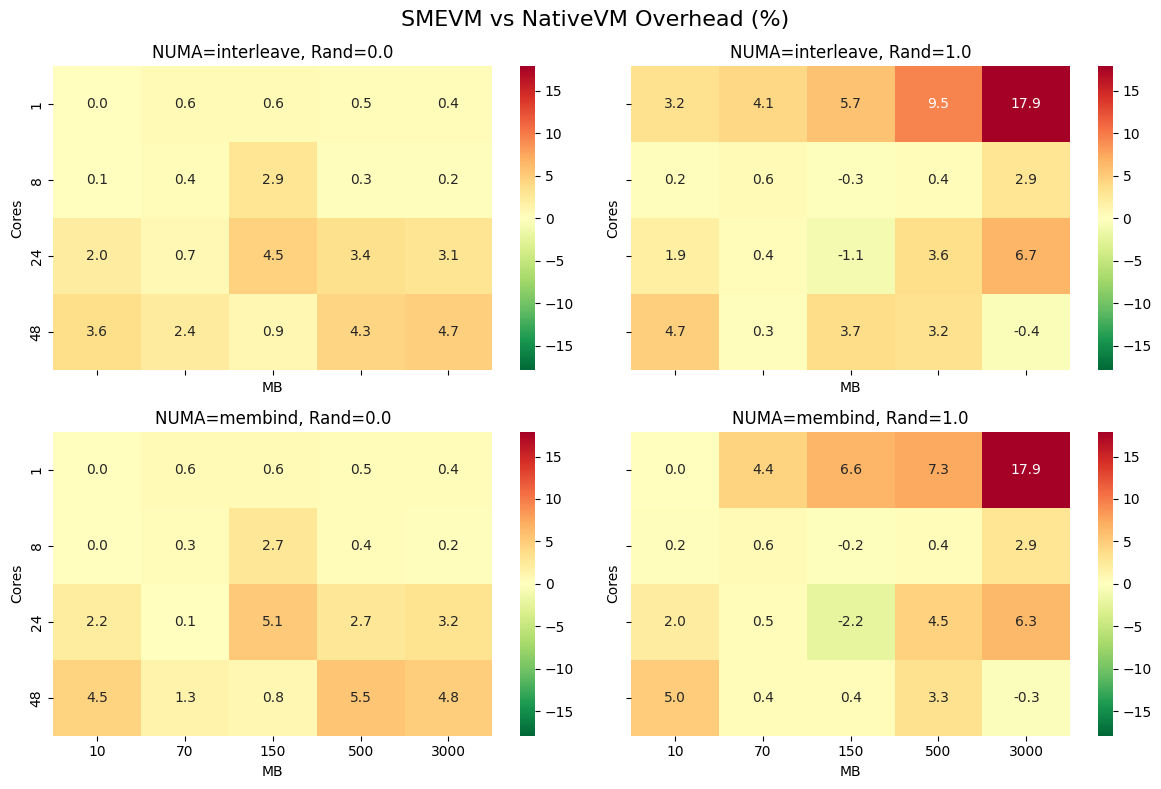

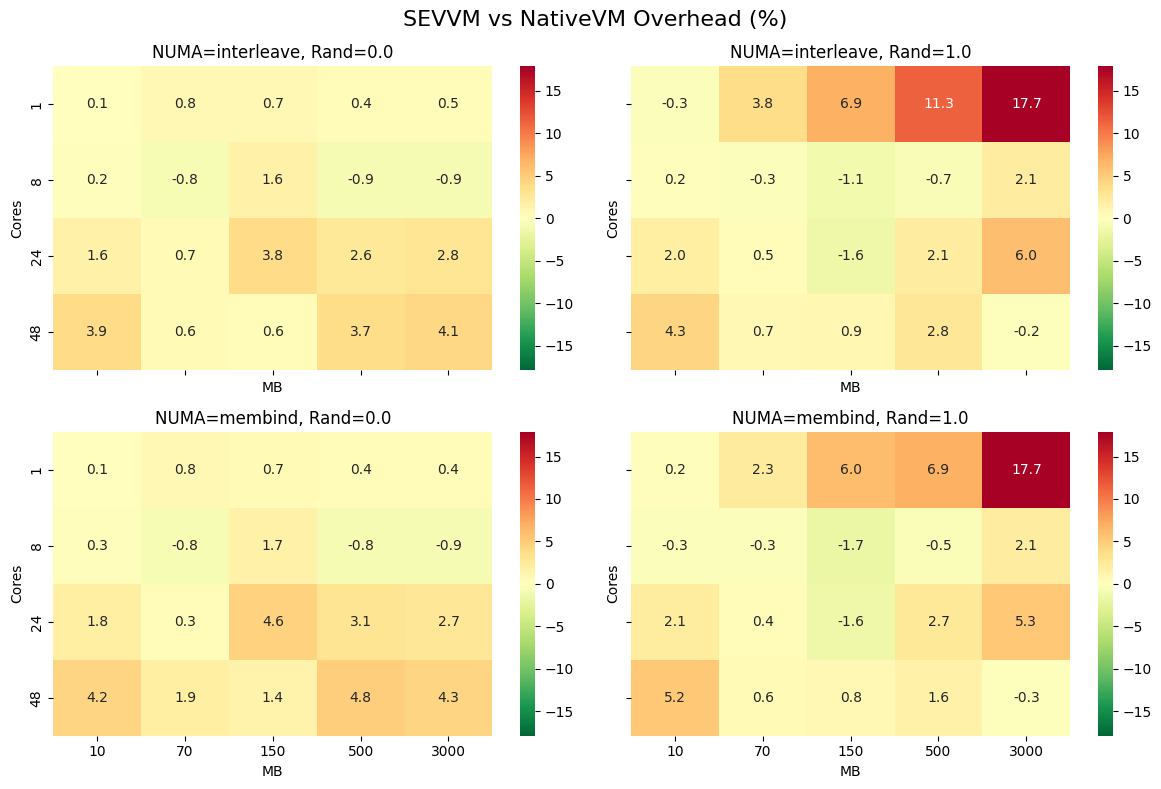

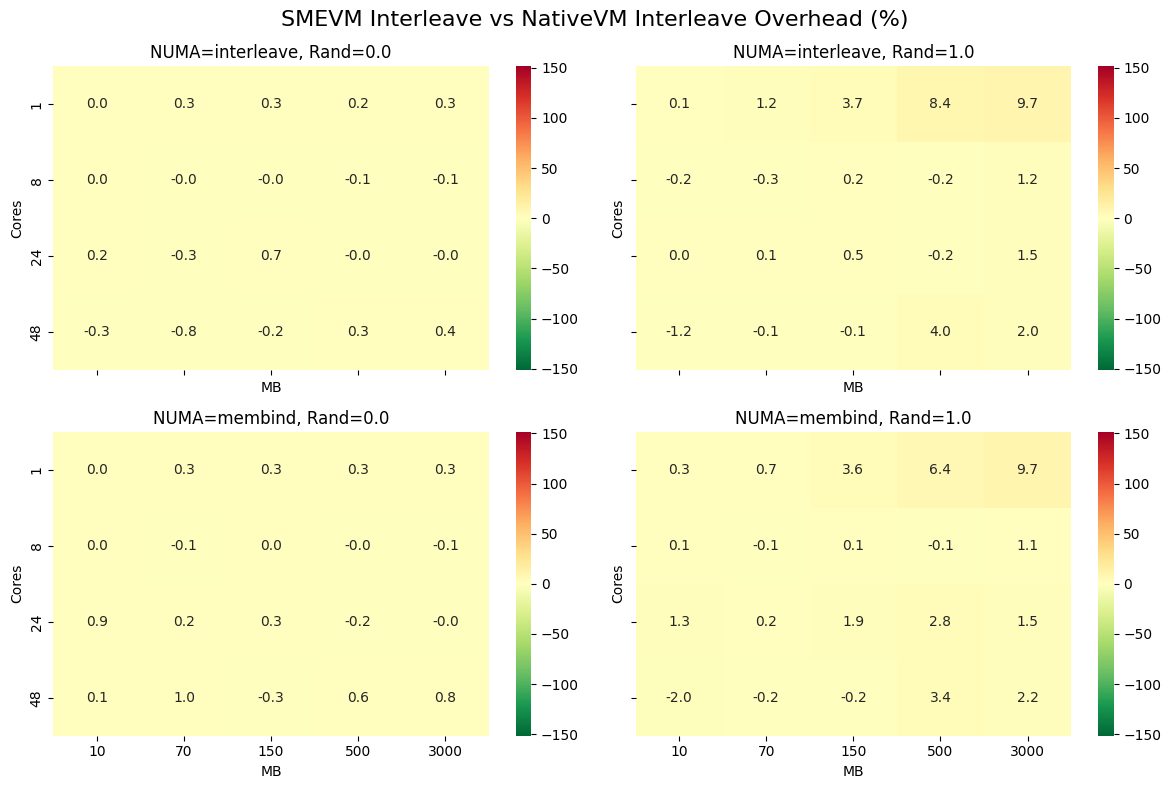

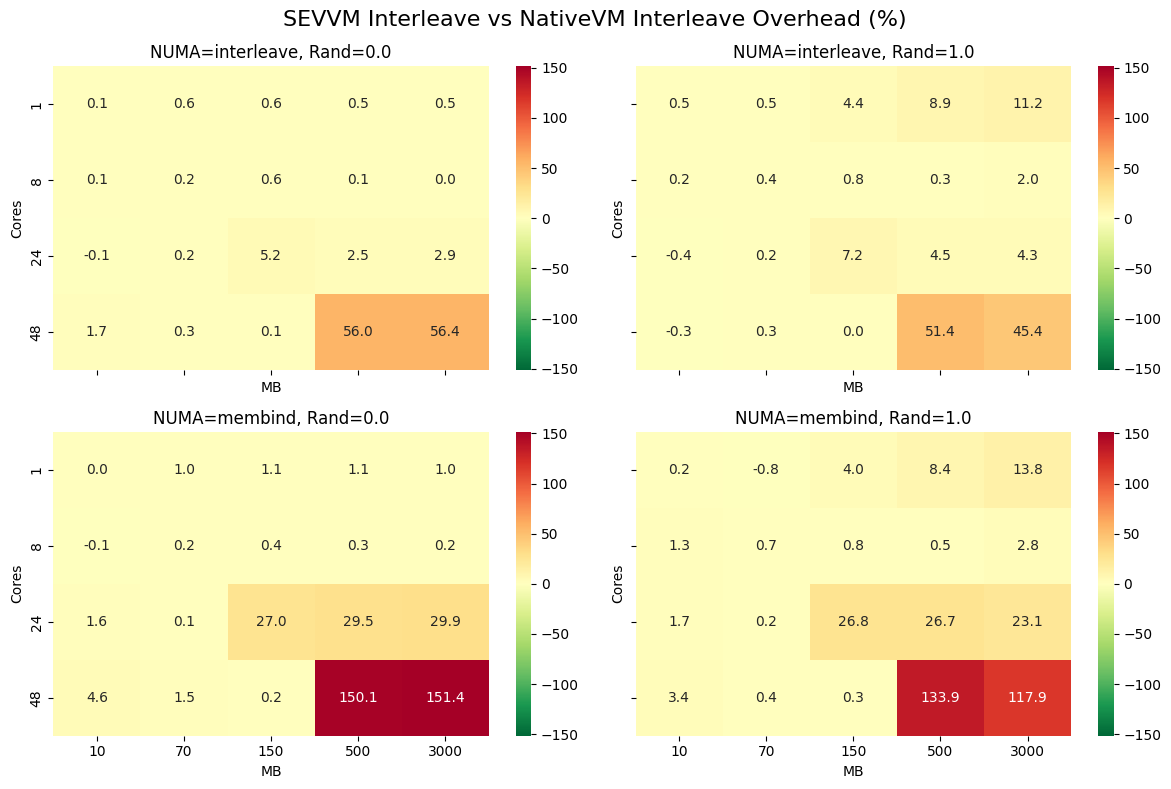

In [ ]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from matplotlib.ticker import FixedLocator
from matplotlib.colors import TwoSlopeNorm

def get_mb(row):
    r_str = str(row['Randomness']).replace('.', '-')
    f_path = os.path.join(matrix_path, f"{r_str}_N{int(row['N'])}.bin")
    return round(os.path.getsize(f_path) / (1024**2))

def get_n(f):
    m = re.search(r'N(\d+)', f)
    return int(m.group(1)) if m else 0

def get_rand(f):
    m = re.search(r'(\d)-(\d)', f)
    return float(f"{m.group(1)}.{m.group(2)}") if m else 0.0

def load_and_process(label, path):
    df = pd.read_csv(path, index_col=False)
    df['Mode'] = label
    df['N'] = df['Matrix'].apply(get_n)
    df['Randomness'] = df['Matrix'].apply(get_rand)
    df['MB'] = df.apply(get_mb, axis=1).round().astype('Int64')
    return df

def compute_overhead_flexible(df_agg, mode, baseline_mode='NativeVM'):
    native = df_agg[df_agg['Mode'] == baseline_mode]
    other  = df_agg[df_agg['Mode'] == mode]

    merged = pd.merge(
        native,
        other,
        on=['Cores', 'MB', 'Randomness', 'NUMA_Policy'],
        suffixes=('_base', f'_{mode}')
    )

    merged['Overhead'] = (
        (merged[f'SpMV_Time_{mode}'] - merged['SpMV_Time_base'])
        / merged['SpMV_Time_base'] * 100
    )
    return merged

def plot_overhead_grid(df_overhead, title, vmin, vmax):
    numa_vals = sorted(df_overhead['NUMA_Policy'].unique())
    rand_vals = sorted(df_overhead['Randomness'].unique())

    fig, axes = plt.subplots(len(numa_vals), len(rand_vals),
                             figsize=(12, 8), sharex=True, sharey=True)

    abs_max = max(abs(vmin), abs(vmax))
    norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

    for i, numa in enumerate(numa_vals):
        for j, rand in enumerate(rand_vals):
            ax = axes[i][j]

            subset = df_overhead[
                (df_overhead['NUMA_Policy'] == numa) &
                (df_overhead['Randomness'] == rand)
            ]

            pivot = subset.pivot(index='Cores', columns='MB', values='Overhead')

            sns.heatmap(
                pivot,
                ax=ax,
                cmap='RdYlGn_r', 
                norm=norm,
                annot=True,
                fmt=".1f"
            )

            ax.set_title(f"NUMA={numa}, Rand={rand}")

    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

files = {
    "NativeVM": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/native/results.csv",
    "SMEVM": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme/results.csv",
    "SEVVM": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev/results.csv",
    "NativeVM_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/native_interleave/results.csv",
    "SMEVM_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme_interleave/results.csv",
    "SEVVM_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev_interleave/results.csv",

}
matrix_path = '../../matrices/spmv'

df_list = [load_and_process(l, p) for l, p in files.items()]
df_raw = pd.concat([d for d in df_list if d is not None])

group_cols = ['Mode', 'Cores', 'MB', 'Randomness', 'NUMA_Policy']
metrics = ['SpMV_Time', 'SpMV_GFLOPS']
df = df_raw.groupby(group_cols)[metrics].mean().reset_index()
df['SpMV_Time_CV'] = (df_raw.groupby(group_cols)['SpMV_Time'].std().values / df['SpMV_Time']) * 100

df_sme_std = compute_overhead_flexible(df, 'SMEVM', 'NativeVM')
df_sev_std = compute_overhead_flexible(df, 'SEVVM', 'NativeVM')

df_sme_int = compute_overhead_flexible(df, 'SMEVM_interleave', 'NativeVM_interleave')
df_sev_int = compute_overhead_flexible(df, 'SEVVM_interleave', 'NativeVM_interleave')

std_min = min(df_sme_std['Overhead'].min(), df_sev_std['Overhead'].min())
std_max = max(df_sme_std['Overhead'].max(), df_sev_std['Overhead'].max())

plot_overhead_grid(df_sme_std, "SMEVM vs NativeVM Overhead (%)", std_min, std_max)
plot_overhead_grid(df_sev_std, "SEVVM vs NativeVM Overhead (%)", std_min, std_max)

int_min = min(df_sme_int['Overhead'].min(), df_sev_int['Overhead'].min())
int_max = max(df_sme_int['Overhead'].max(), df_sev_int['Overhead'].max())

plot_overhead_grid(df_sme_int, "SMEVM Interleave vs NativeVM Interleave Overhead (%)", int_min, int_max)
plot_overhead_grid(df_sev_int, "SEVVM Interleave vs NativeVM Interleave Overhead (%)", int_min, int_max)

In [ ]:
def load_iteration_data(label, base_path):
    all_iters = []
    
    for folder_name in os.listdir(base_path):
        folder_path = os.path.join(base_path, folder_name)
        csv_path = os.path.join(folder_path, "iter.csv")
        
        if os.path.isdir(folder_path) and os.path.exists(csv_path):
            match = re.search(r'(\d-\d)_N(\d+)_c(\d+)_(\w+)', folder_name)
            if match:
                rand_str, n_val, cores, numa = match.groups()
                
                it_df = pd.read_csv(csv_path)
                
                it_df['Mode'] = label
                it_df['Randomness'] = float(rand_str.replace('-', '.'))
                it_df['N'] = int(n_val)
                it_df['Cores'] = int(cores)
                it_df['NUMA_Policy'] = numa
                
                dummy_row = {'Randomness': it_df['Randomness'].iloc[0], 'N': it_df['N'].iloc[0]}
                it_df['MB'] = get_mb(dummy_row)
                
                all_iters.append(it_df)
                
    return pd.concat(all_iters, ignore_index=True) if all_iters else None

iter_folder = {
	"NativeVM": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/native/extra/",
	"SMEVM": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme/extra/",
	"SEVVM": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev/extra/",
}

iter_dfs = []
for mode, path in iter_folder.items():
    print(f"Loading iterations for {mode}...")
    mode_iter_df = load_iteration_data(mode, path)
    if mode_iter_df is not None:
        iter_dfs.append(mode_iter_df)

df_iters = pd.concat(iter_dfs, ignore_index=True)
df_iters


Loading iterations for NativeVM...
Loading iterations for SMEVM...
Loading iterations for SEVVM...


,Run,Iter,Time,GFLOPS,Mode,Randomness,N,Cores,NUMA_Policy,MB
0,1,1,0.003373,7.68614,NativeVM,0.0,432105,48,membind,150
1,1,2,0.000194,133.55200,NativeVM,0.0,432105,48,membind,150
2,1,3,0.000175,147.94800,NativeVM,0.0,432105,48,membind,150
3,1,4,0.000248,104.46200,NativeVM,0.0,432105,48,membind,150
4,1,5,0.000185,140.20700,NativeVM,0.0,432105,48,membind,150
...,...,...,...,...,...,...,...,...,...,...
204330820,15,79,0.118924,4.36015,SEVVM,1.0,8642110,48,interleave,3000
204330821,15,80,0.119230,4.34898,SEVVM,1.0,8642110,48,interleave,3000
204330822,15,81,0.118961,4.35880,SEVVM,1.0,8642110,48,interleave,3000
204330823,15,82,0.119104,4.35356,SEVVM,1.0,8642110,48,interleave,3000


<Axes: xlabel='Iter', ylabel='GFLOPS'>

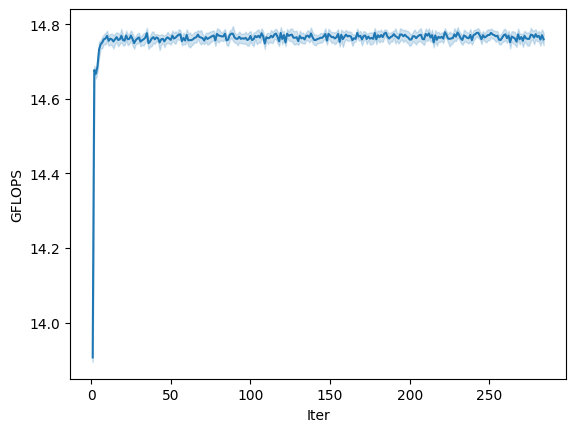

In [24]:
subdf = df_iters[(df_iters['Mode'] == 'NativeVM') & (df_iters['Randomness'] == 0.0) & (df_iters['N'] == 8642110) & (df_iters['Cores'] == 48) & (df_iters['NUMA_Policy'] == 'membind')]
sns.lineplot(data=subdf, x='Iter', y='GFLOPS')